In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (10,5)

In [2]:
DATASET = Path(
    r"C:\Users\Ashal.Meeqaat\Desktop\Medical_KG_Project\datasets\raw"
)

SIDER = DATASET / "SIDER"

DRUGS = SIDER / "drug_names.tsv"

SIDE_EFFECTS = SIDER / "meddra_all_se.tsv" / "meddra_all_se.tsv"

FREQUENCY = SIDER / "meddra_freq.tsv"/ "meddra_freq.tsv"

INDICATIONS = SIDER / "meddra_all_indications.tsv"/ "meddra_all_indications.tsv"

In [3]:
drug_names = pd.read_csv(
    DRUGS,
    sep="\t",
    header=None
)

drug_names.head()

,0,1
0,CID100000085,carnitine
1,CID100000119,gamma-aminobutyric
2,CID100000137,5-aminolevulinic
3,CID100000143,leucovorin
4,CID100000146,5-methyltetrahydrofolate


In [4]:
side_effects = pd.read_csv(
    SIDE_EFFECTS,
    sep="\t",
    header=None,
    low_memory=False
)

side_effects.head()

,0,1,2,3,4,5
0,CID100000085,CID000010917,C0000729,LLT,C0000729,Abdominal cramps
1,CID100000085,CID000010917,C0000729,PT,C0000737,Abdominal pain
2,CID100000085,CID000010917,C0000737,LLT,C0000737,Abdominal pain
3,CID100000085,CID000010917,C0000737,PT,C0687713,Gastrointestinal pain
4,CID100000085,CID000010917,C0000737,PT,C0000737,Abdominal pain


In [5]:
frequency = pd.read_csv(
    FREQUENCY,
    sep="\t",
    header=None,
    low_memory=False
)

frequency.head()

,0,1,2,3,4,5,6,7,8,9
0,CID100000085,CID000010917,C0000737,NaN,21%,0.21,0.21,LLT,C0000737,Abdominal pain
1,CID100000085,CID000010917,C0000737,NaN,21%,0.21,0.21,PT,C0000737,Abdominal pain
2,CID100000085,CID000010917,C0000737,NaN,21%,0.21,0.21,PT,C0687713,Gastrointestinal pain
3,CID100000085,CID000010917,C0000737,NaN,5%,0.05,0.05,LLT,C0000737,Abdominal pain
4,CID100000085,CID000010917,C0000737,NaN,5%,0.05,0.05,PT,C0000737,Abdominal pain


In [6]:
indications = pd.read_csv(
    INDICATIONS,
    sep="\t",
    header=None,
    low_memory=False
)

indications.head()

,0,1,2,3,4,5,6
0,CID100000085,C0015544,text_mention,Failure to Thrive,LLT,C0015544,Failure to thrive
1,CID100000085,C0015544,text_mention,Failure to Thrive,PT,C0015544,Failure to thrive
2,CID100000085,C0020615,text_mention,Hypoglycemia,LLT,C0020615,Hypoglycaemia
3,CID100000085,C0020615,text_mention,Hypoglycemia,PT,C0020615,Hypoglycaemia
4,CID100000085,C0022661,NLP_indication,"Kidney Failure, Chronic",LLT,C0022661,Renal failure chronic


In [7]:
drug_names.columns = [
    "drug_id",
    "drug_name"
]

In [8]:
side_effects.columns = [
    "drug_id_flat",
    "drug_id_stereo",
    "umls_id",
    "term_type",
    "side_effect_id",
    "side_effect_name"
]

In [9]:
frequency.columns = [
    "drug_id_flat",
    "drug_id_stereo",
    "umls_id",
    "placebo",
    "frequency",
    "lower_bound",
    "upper_bound",
    "term_type",
    "side_effect_id",
    "side_effect_name"
]

In [10]:
indications.columns = [
    "drug_id",
    "disease_umls",
    "method",
    "disease_name",
    "term_type",
    "meddra_id",
    "meddra_name"
]

In [11]:
def dataset_overview(df, name):
    print("="*60)
    print(name)
    print("="*60)

    print(f"Rows    : {len(df):,}")
    print(f"Columns : {len(df.columns)}")

    print("\nMissing Values")
    print(df.isna().sum())

    print("\nDuplicate Rows")
    print(df.duplicated().sum())

    print("\nMemory")
    print(round(df.memory_usage(deep=True).sum()/1024**2,2),"MB")

    print()

In [12]:
dataset_overview(drug_names,"Drug Names")
dataset_overview(side_effects,"Side Effects")
dataset_overview(frequency,"Frequency")
dataset_overview(indications,"Indications")

Drug Names
Rows    : 1,430
Columns : 2

Missing Values
drug_id      0
drug_name    0
dtype: int64

Duplicate Rows
0

Memory
0.05 MB

Side Effects
Rows    : 309,849
Columns : 6

Missing Values
drug_id_flat          0
drug_id_stereo        0
umls_id               0
term_type           901
side_effect_id      901
side_effect_name      0
dtype: int64

Duplicate Rows
0

Memory
31.07 MB

Frequency
Rows    : 291,632
Columns : 10

Missing Values
drug_id_flat             0
drug_id_stereo           0
umls_id                  0
placebo             253732
frequency                0
lower_bound              0
upper_bound              0
term_type              419
side_effect_id         419
side_effect_name         0
dtype: int64

Duplicate Rows
0

Memory
39.57 MB

Indications
Rows    : 30,835
Columns : 7

Missing Values
drug_id          0
disease_umls     0
method           0
disease_name     0
term_type       41
meddra_id       41
meddra_name      0
dtype: int64

Duplicate Rows
0

Memory
3.91 MB



In [13]:
print("Unique Drugs")

print(drug_names["drug_id"].nunique())

Unique Drugs
1430


In [14]:
print("Unique Side Effects")

print(side_effects["side_effect_name"].nunique())

Unique Side Effects
6123


In [15]:
print("Unique Diseases")

print(indications["disease_name"].nunique())

Unique Diseases
2714


In [16]:
print("="*60)
print("GRAPH STATISTICS")
print("="*60)

print("Drug Nodes :", drug_names["drug_id"].nunique())

print("Side Effect Nodes :", side_effects["side_effect_id"].nunique())

print("Disease Nodes :", indications["disease_umls"].nunique())

print("Drug→SideEffect Relationships :", len(side_effects))

print("Drug→Disease Relationships :", len(indications))

GRAPH STATISTICS
Drug Nodes : 1430
Side Effect Nodes : 6060
Disease Nodes : 2714
Drug→SideEffect Relationships : 309849
Drug→Disease Relationships : 30835


side_effect_name
Dizziness                     2826
Nausea                        2601
Headache                      2416
Rash                          2403
Vomiting                      2345
Asthenia                      2264
Diarrhoea                     2200
Pruritus                      2049
Hypersensitivity              1952
Abdominal pain                1839
Urticaria                     1744
Body temperature increased    1714
Dermatitis                    1676
Pain                          1657
Gastrointestinal disorder     1624
Fatigue                       1560
Dyspepsia                     1536
Constipation                  1526
Dyspnoea                      1511
Hypotension                   1483
Name: count, dtype: int64

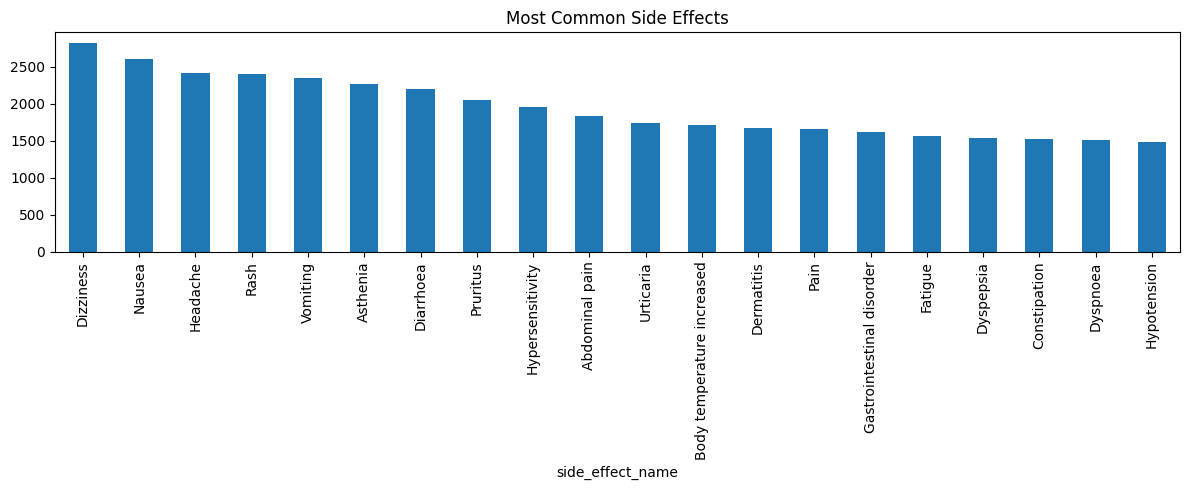

In [17]:
top_side_effects = (
    side_effects["side_effect_name"]
    .value_counts()
)

display(top_side_effects.head(20))
top_side_effects.head(20).plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Most Common Side Effects")

plt.tight_layout()

plt.show()

In [18]:
top_diseases = (
    indications["disease_name"]
    .value_counts()
)

display(top_diseases.head(20))

disease_name
Renal Insufficiency         450
Communicable Diseases       420
Hypertensive disease        272
Myocardial Infarction       255
Liver diseases              244
Malignant Neoplasms         242
Pain                        178
Neoplasms                   174
Diabetes Mellitus           162
Hypersensitivity            160
Rheumatoid Arthritis        156
Asthma                      156
Lymphoma                    138
Congestive heart failure    136
Nausea                      126
Hemorrhage                  126
Seizures                    124
Vomiting                    116
Dermatologic disorders      114
Urinary tract infection     114
Name: count, dtype: int64

In [19]:
drug_usage = (
    side_effects["drug_id_flat"]
    .value_counts()
)

drug_usage.head(20)

drug_id_flat
CID100002771    2185
CID100005372    2016
CID100060795    1610
CID100001690    1583
CID100125889    1526
CID100004666    1364
CID100005095    1298
CID100005073    1270
CID100004885    1266
CID100093860    1194
CID100004583    1193
CID100005523    1164
CID100004691    1135
CID100005538    1058
CID100005656    1052
CID100005514    1036
CID100003386    1014
CID100003883    1010
CID171306834    1002
CID100001972     999
Name: count, dtype: int64

In [20]:
frequency["frequency"].value_counts().head(20)

frequency
postmarketing    41655
1%               14885
0%               13906
infrequent       13089
rare             12600
2%               11320
uncommon         10054
common            9178
3%                8558
4%                6383
5%                5722
6%                4672
7%                3721
very rare         3564
8%                3263
frequent          3069
9%                2743
10%               2521
very common       2395
11%               2197
Name: count, dtype: int64

# Neo4j Feasibility

Nodes

- Drug
- Side Effect
- Disease

Relationships

- HAS_SIDE_EFFECT
- TREATS

Relationship Properties

- Frequency
- Lower Bound
- Upper Bound
- Term Type

Overall Rating

⭐⭐⭐⭐⭐

# Dashboard

Cards

- Total Drugs
- Total Diseases
- Total Side Effects
- Drug → Disease Graph
- Drug → Side Effect Graph
- Most Common Side Effects
- Most Prescribed Drugs
- Frequency Distribution

In [21]:
def quality_report(df, name):
    print("="*60)
    print(name)
    print("="*60)

    print(f"Rows              : {len(df):,}")
    print(f"Duplicate Rows    : {df.duplicated().sum():,}")

    print("\nMissing Values")
    print(df.isna().sum())

    print("\nUnique IDs")

    for col in df.columns:
        if "id" in col.lower():
            print(f"{col:<20} {df[col].nunique():,}")

    print("\n")

In [22]:
quality_report(drug_names, "Drug Names")
quality_report(side_effects, "Side Effects")
quality_report(frequency, "Frequency")
quality_report(indications, "Indications")

Drug Names
Rows              : 1,430
Duplicate Rows    : 0

Missing Values
drug_id      0
drug_name    0
dtype: int64

Unique IDs
drug_id              1,430


Side Effects
Rows              : 309,849
Duplicate Rows    : 0

Missing Values
drug_id_flat          0
drug_id_stereo        0
umls_id               0
term_type           901
side_effect_id      901
side_effect_name      0
dtype: int64

Unique IDs
drug_id_flat         1,430
drug_id_stereo       1,556
umls_id              5,868
side_effect_id       6,060
side_effect_name     6,123


Frequency
Rows              : 291,632
Duplicate Rows    : 0

Missing Values
drug_id_flat             0
drug_id_stereo           0
umls_id                  0
placebo             253732
frequency                0
lower_bound              0
upper_bound              0
term_type              419
side_effect_id         419
side_effect_name         0
dtype: int64

Unique IDs
drug_id_flat         968
drug_id_stereo       1,035
umls_id              3,775
side_e

In [23]:
missing_drugs = set(indications["drug_id"]) - set(drug_names["drug_id"])

len(missing_drugs)

77

In [24]:
missing_drugs

{'CID100000242',
 'CID100000274',
 'CID100000604',
 'CID100000723',
 'CID100001023',
 'CID100001176',
 'CID100001292',
 'CID100002612',
 'CID100002645',
 'CID100002735',
 'CID100003054',
 'CID100003641',
 'CID100003680',
 'CID100004734',
 'CID100005199',
 'CID100005202',
 'CID100005281',
 'CID100005772',
 'CID100005832',
 'CID100008813',
 'CID100013344',
 'CID100016759',
 'CID100019190',
 'CID100021630',
 'CID100021826',
 'CID100024083',
 'CID100024393',
 'CID100024550',
 'CID100025517',
 'CID100027686',
 'CID100028696',
 'CID100033030',
 'CID100034058',
 'CID100048175',
 'CID100054889',
 'CID100056801',
 'CID100061520',
 'CID100061635',
 'CID100064642',
 'CID100072396',
 'CID100092725',
 'CID100104727',
 'CID100105153',
 'CID100114753',
 'CID100130565',
 'CID100132970',
 'CID100151174',
 'CID100161580',
 'CID100163158',
 'CID100164521',
 'CID100316280',
 'CID100441086',
 'CID100517044',
 'CID103037258',
 'CID105281074',
 'CID109548591',
 'CID109552070',
 'CID109577580',
 'CID109810246

In [25]:
side_effects[
    side_effects["side_effect_id"].isna()
].head(20)

,drug_id_flat,drug_id_stereo,umls_id,term_type,side_effect_id,side_effect_name
307,CID100000137,CID000000137,C0851353,NaN,NaN,Blood and lymphatic system disorders
667,CID100000158,CID005280360,C0851353,NaN,NaN,Blood and lymphatic system disorders
916,CID100000159,CID005282411,C0851353,NaN,NaN,Blood and lymphatic system disorders
976,CID100000160,CID005280363,C0851353,NaN,NaN,Blood and lymphatic system disorders
1141,CID100000191,CID000060961,C0206277,NaN,NaN,Fatal outcomes
2078,CID100000298,CID000005959,C0851353,NaN,NaN,Blood and lymphatic system disorders
2822,CID100000444,CID000000444,C0039338,NaN,NaN,Taste disorders
3255,CID100000444,CID000000444,C0851354,NaN,NaN,Ear and labyrinth disorders
4105,CID100000450,CID000005757,C0851353,NaN,NaN,Blood and lymphatic system disorders
4106,CID100000450,CID000005757,C0851354,NaN,NaN,Ear and labyrinth disorders


In [26]:
import pandas as pd
import os

EXPORT = r"C:\Users\Ashal.Meeqaat\Desktop\Medical_KG_Project\datasets\processed\SIDER\csv"
os.makedirs(EXPORT, exist_ok=True)

##################################################
# Drug Nodes
##################################################

drug = drug_names.copy()
drug.columns = ["id", "name"]

drug.to_csv(
    os.path.join(EXPORT, "Drug.csv"),
    index=False
)

##################################################
# Side Effect Nodes
##################################################

side = (
    side_effects[["side_effect_id", "side_effect_name"]]
    .dropna()
    .drop_duplicates()
)

side.columns = ["id", "name"]

side.to_csv(
    os.path.join(EXPORT, "SideEffect.csv"),
    index=False
)

##################################################
# Disease Nodes (Indications)
##################################################

disease = (
    indications[["meddra_id", "meddra_name"]]
    .dropna()
    .drop_duplicates()
)

disease.columns = ["id", "name"]

disease.to_csv(
    os.path.join(EXPORT, "Disease.csv"),
    index=False
)

##################################################
# Drug -> Side Effect
##################################################

has_side_effect = (
    side_effects[["drug_id_flat", "side_effect_id"]]
    .dropna()
    .drop_duplicates()
)

has_side_effect.columns = ["source", "target"]

has_side_effect.to_csv(
    os.path.join(EXPORT, "HAS_SIDE_EFFECT.csv"),
    index=False
)

##################################################
# Drug -> Disease
##################################################

treats = (
    indications[["drug_id", "meddra_id"]]
    .dropna()
    .drop_duplicates()
)

treats.columns = ["source", "target"]

treats.to_csv(
    os.path.join(EXPORT, "TREATS.csv"),
    index=False
)

##################################################

print("Drug:", len(drug))
print("Disease:", len(disease))
print("Side Effects:", len(side))
print("HAS_SIDE_EFFECT:", len(has_side_effect))
print("TREATS:", len(treats))

Drug: 1430
Disease: 3045
Side Effects: 6060
HAS_SIDE_EFFECT: 162364
TREATS: 17839
